# Power scan — full intensity-fluctuation model

Everything is saved under `results/<date>/<TITLE>/`. Plots use the interactive **ipympl**
backend: drag to zoom, home button to reset.

In [1]:
TITLE    = "POWESCAN__single_700-10_520-40_420-10___NIR3"   # results/<date>/<TITLE>/ ...
DAY      = "Jun23"
MATERIAL = "CdTe110"               # bare sample name (config goes in CONFIG)

CONFIG = {                          # optical configuration, saved into every pkl
    "P1": False, "P3": False,
    "filters": {"H3": "700-10", "H4": "520-40", "H5": "420-10"},
    "filter_layout": "single",
    "density": "NIR3"
}

# --- how the pump power is set: rotate the wave-plate to the angle giving each power ---
# Malus model:  P(theta) = offset + p_max * cos^2( factor * (theta - theta0) )
#   factor = 2  -> half-wave plate + fixed polariser (45 deg rotation = full min->max)
#   factor = 1  -> rotating polariser / analyser
# CALIBRATE these with a power meter first:
#   theta0 = angle of MAXIMUM power, p_max = that maximum (mW), offset = residual min (mW).
SET_ANGLE_FROM_POWER = True        # True: derive the angle from each power below
MALUS = {"p_max": 100.0, "theta0": 0.0, "offset": 0.0, "factor": 2.0}

# --- the power scan: the powers (mW) you want; angle is computed from MALUS ---
# (set "angle_deg" explicitly to override, or SET_ANGLE_FROM_POWER=False to move by hand)
POWER_POINTS = [
    {"power_mw": 20.0,  "angle_deg": None},
    {"power_mw": 25.0,  "angle_deg": None},
    {"power_mw": 50.0,  "angle_deg": None},
    {"power_mw": 80.0,  "angle_deg": None},
]
CHUNK_MINUTES = 1.0
MAX_CHUNKS    = 2

# --- dense intensity scan for a smooth K(n) (count-rate only, optional) ---
DO_DENSE_SCAN   = True
DENSE_ANGLES    = list(range(0, 91, 3))   # wave-plate angles (deg); power per angle via MALUS
DENSE_SECONDS   = 3.0

# --- analysis ---
HARMONICS  = (3, 5)        # H4 is usually a dark/degenerate channel here
TAU_IN_NS  = 4.0
G2_METHOD  = "delay"       # 'delay' | 'direct' | 'heralded'
K_POLY_DEG = 3             # smoothing degree of the dense log-log K(n) fit

# --- time tagger ---
CHANNELS        = [1, 2, 3, 4, 5, 6]
MODE_ON_CHANNEL = ["H3T", "H3R", "H4T", "H4R", "H5T", "H5R"]
DELAYS_PS       = [0, 0, 0, 0, 0, 0]
TRIGGER_V       = 0.5
BINWIDTH_PS     = 100
NUM_BINS        = 50000
COINC_WINDOW_PS = 25000
REP_RATE_HZ     = 18.66e6
WAVELENGTH_NM   = 2100

LIVE_HARDWARE = True
PRM1_SERIAL   = "27264707"   # wave-plate stage


In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src" / "core.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

DATA_DIR    = ROOT / "data" / DAY / TITLE
DENSE_DIR   = ROOT / "data" / DAY / f"{TITLE}_intensity"
RESULTS_DIR = ROOT / "results"
print("Project root:", ROOT)
print("Scan ->", DATA_DIR)

Project root: c:\Users\QUANTUM\Desktop\Quantum_SHHG
Scan -> c:\Users\QUANTUM\Desktop\Quantum_SHHG\data\Jun23\POWESCAN__single_700-10_520-40_420-10___NIR3


## 1. Acquire the power scan

In [3]:
from src.acquisition import (Acquisition, AcquisitionConfig, LaserParams,
                             TimeTaggerParams, ChunkingParams, ScanPoint)
from src.measurement import CombinedRecorder, CountrateRecorder
from src.hardware import RotationStageController

SCAN_PATH = None
DENSE_PATH = None

def _tt():
    return TimeTaggerParams(channels=CHANNELS, mode_on_channel=MODE_ON_CHANNEL,
                            trigger_levels_v=TRIGGER_V, delays_ps=DELAYS_PS,
                            binwidth_ps=BINWIDTH_PS, num_bins=NUM_BINS,
                            coincidence_window_ps=COINC_WINDOW_PS)

if LIVE_HARDWARE:
    cfg = AcquisitionConfig(
        base_dir=DATA_DIR, material=MATERIAL, experiment_type="g2_heralded_virtual",
        configuration=CONFIG, laser=LaserParams(rep_rate_hz=REP_RATE_HZ, wavelength_nm=WAVELENGTH_NM),
        timetagging=_tt(),
        chunking=ChunkingParams(enabled=True, chunk_minutes=CHUNK_MINUTES,
                                max_chunks=MAX_CHUNKS, stop_when_reached=False))
    stages = RotationStageController([PRM1_SERIAL]) if any(p["angle_deg"] is not None for p in POWER_POINTS) else None
    with Acquisition(cfg, recorder=CombinedRecorder(), stages=stages) as acq:
        points = [ScanPoint(power_mw=p["power_mw"], angle_deg=p["angle_deg"],
                            stage_id=(PRM1_SERIAL if p["angle_deg"] is not None else None),
                            label=f'{p["power_mw"]:g}mW') for p in POWER_POINTS]
        acq.run_scan(points)
        SCAN_PATH = acq.save_dir
    print("Power scan ->", SCAN_PATH)
else:
    print("[offline] LIVE_HARDWARE is False — set SCAN_PATH below to analyse existing data.")

2026-06-23 16:50:40,703 [INFO]  ==================== ACQUISITION SETUP ====================
2026-06-23 16:50:40,852 [INFO]  Found 1 connected Time Tagger(s)
2026-06-23 16:50:43,702 [INFO]  Time Tagger initialised (serial=225000139A, model=Time Tagger Ultra, resolution=Standard).
2026-06-23 16:50:43,703 [INFO]  Trigger level ch 1: 0.500 V
2026-06-23 16:50:43,704 [INFO]  Trigger level ch 2: 0.500 V
2026-06-23 16:50:43,706 [INFO]  Trigger level ch 3: 0.500 V
2026-06-23 16:50:43,707 [INFO]  Trigger level ch 4: 0.500 V
2026-06-23 16:50:43,708 [INFO]  Trigger level ch 5: 0.500 V
2026-06-23 16:50:43,711 [INFO]  Trigger level ch 6: 0.500 V
2026-06-23 16:50:43,711 [INFO]  Recorder: combined
2026-06-23 16:50:43,713 [INFO]  Chunked acquisition '20mW_num0' (chunk=1.00 min, max=2).
2026-06-23 16:50:43,714 [INFO]  Chunk 1/2 | elapsed 1.0 min
2026-06-23 16:50:43,715 [INFO]  Correlation recording: mode=g2_heralded_virtual, virtual=True, phys_hist=True
2026-06-23 16:50:43,716 [INFO]  Harmonic modes: {'

Power scan -> c:\Users\QUANTUM\Desktop\Quantum_SHHG\data\Jun23\POWESCAN__single_700-10_520-40_420-10___NIR3\2026-06-23_16-50-40_g2_heralded_virtual


## 1bis. Dense intensity scan (optional)

Count-rate-only sweep of the half-wave-plate angle. Cheap, and gives many extra points for a
smooth $K(n)$. Power per angle is recovered from Malus' law (`MALUS`).

In [4]:
# NOTE: the Thorlabs Kinesis app (or any other app using the PRM1 stage) must be CLOSED
# before running this cell. Kinesis grants exclusive USB access — two processes cannot
# hold the device at the same time. Acquisition.setup() will raise a clear error if it
# cannot connect, so you will know immediately.
if LIVE_HARDWARE and DO_DENSE_SCAN:
    cfg_d = AcquisitionConfig(
        base_dir=DENSE_DIR, material=MATERIAL, experiment_type="intensity_scan",
        configuration=CONFIG, laser=LaserParams(rep_rate_hz=REP_RATE_HZ, wavelength_nm=WAVELENGTH_NM),
        timetagging=_tt())
    stages = RotationStageController([PRM1_SERIAL])   # .connect() is called inside Acquisition.setup()
    with Acquisition(cfg_d, recorder=CountrateRecorder(), stages=stages) as acq:
        for th in DENSE_ANGLES:
            acq.run_point(ScanPoint(angle_deg=th, stage_id=PRM1_SERIAL, label=f"ang_{th:g}"),
                          duration_s=DENSE_SECONDS)
        DENSE_PATH = acq.save_dir
    print("Dense intensity scan ->", DENSE_PATH)
else:
    print("[offline or disabled] dense scan skipped.")


2026-06-23 16:58:48,210 [INFO]  ==================== ACQUISITION SETUP ====================
2026-06-23 16:58:48,271 [INFO]  Found 1 connected Time Tagger(s)
2026-06-23 16:58:51,065 [INFO]  Time Tagger initialised (serial=225000139A, model=Time Tagger Ultra, resolution=Standard).
2026-06-23 16:58:51,066 [INFO]  Trigger level ch 1: 0.500 V
2026-06-23 16:58:51,067 [INFO]  Trigger level ch 2: 0.500 V
2026-06-23 16:58:51,068 [INFO]  Trigger level ch 3: 0.500 V
2026-06-23 16:58:51,069 [INFO]  Trigger level ch 4: 0.500 V
2026-06-23 16:58:51,070 [INFO]  Trigger level ch 5: 0.500 V
2026-06-23 16:58:51,074 [INFO]  Trigger level ch 6: 0.500 V
2026-06-23 16:58:51,075 [INFO]  Recorder: countrate
2026-06-23 16:58:51,988 [INFO]  Time Tagger freed (serial=225000139A).
2026-06-23 16:58:51,988 [INFO]  All rotation stages disconnected.
2026-06-23 16:58:51,989 [INFO]  Acquisition teardown complete.


RuntimeError: No rotation stages connected.

In [ ]:
# --- offline fallback: point at existing data (edit these paths) ---
if SCAN_PATH is None:
    SCAN_PATH = ROOT / "data" / "Jun16" / "PowerScan_GaAs100_P1"
print("Analysing scan:", SCAN_PATH)
print("Dense K(n) from:", DENSE_PATH)

Analysing scan: c:\Users\QUANTUM\Desktop\Quantum_SHHG\data\Jun16\PowerScan_GaAs100_P1
Dense K(n) from: None


## 2. Full model + save

Builds and saves the four model plots + a 2x2 dashboard under `results/<date>/<TITLE>/model/`.
Pass `intensity_runs=DENSE_PATH` + `malus=MALUS` to use the dense $K(n)$.

AnalysisReport 'POWESCAN__single_700-10_520-40_420-10___NIR3': 4 run(s) (comparison), source=physical
  -> results: c:\Users\QUANTUM\Desktop\Quantum_SHHG\results\2026-06-23\POWESCAN__single_700-10_520-40_420-10___NIR3
PowerScanReport 'POWESCAN__single_700-10_520-40_420-10___NIR3': 4 powers (20-80 mW)
  -> results: c:\Users\QUANTUM\Desktop\Quantum_SHHG\results\2026-06-23\POWESCAN__single_700-10_520-40_420-10___NIR3
   P(mW)         I3         I5     K3     K5   g2_33   g2_55  (g-1)/K2_3  (g-1)/K2_5
------------------------------------------------------------------------------------
    20.0  3.804e+04  1.577e+04  -0.56  -0.53   8.513  14.389     23.8933     48.4581
    25.0  3.356e+04  1.403e+04  -0.39  -0.37   9.281  17.432     53.8225    120.7563
    50.0  3.676e+04  1.522e+04   0.13   0.11   8.799  14.590    479.7556   1050.2098
    80.0  3.898e+04  1.604e+04   0.13   0.11   8.368  13.957    471.4261   1054.7324


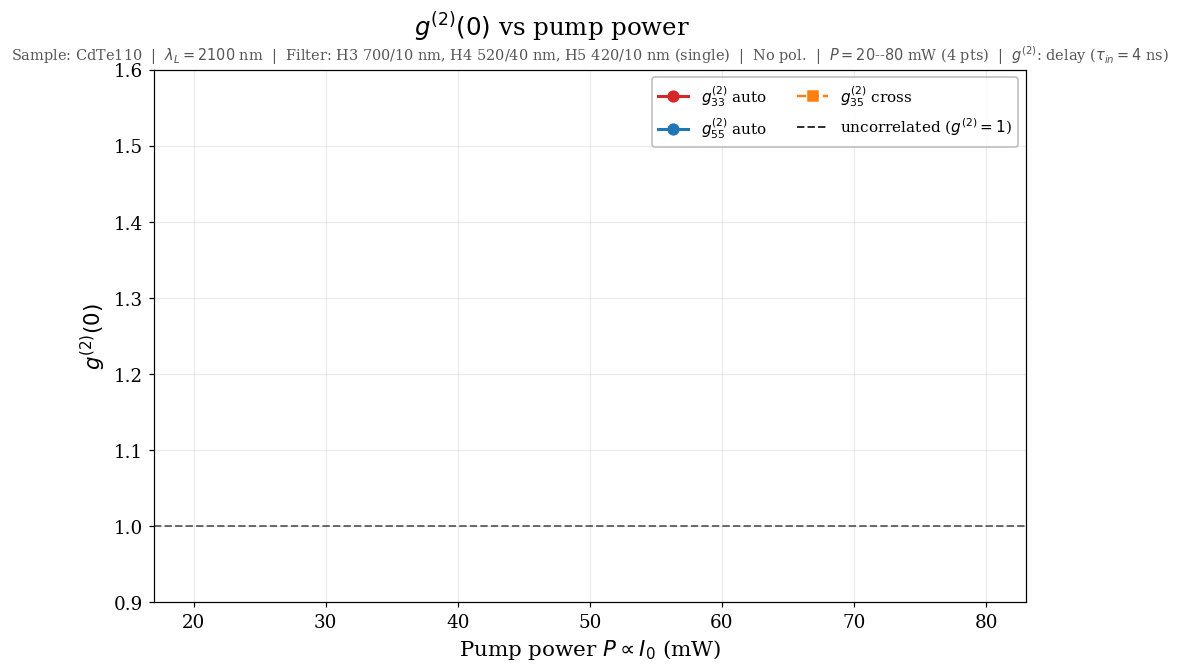

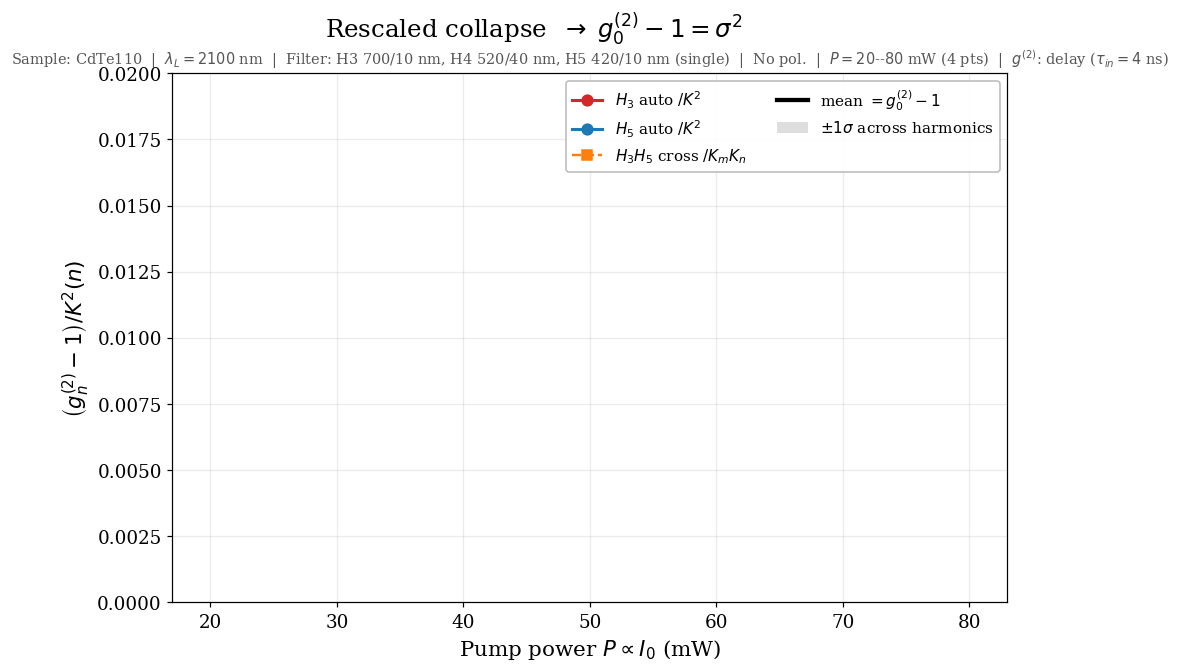

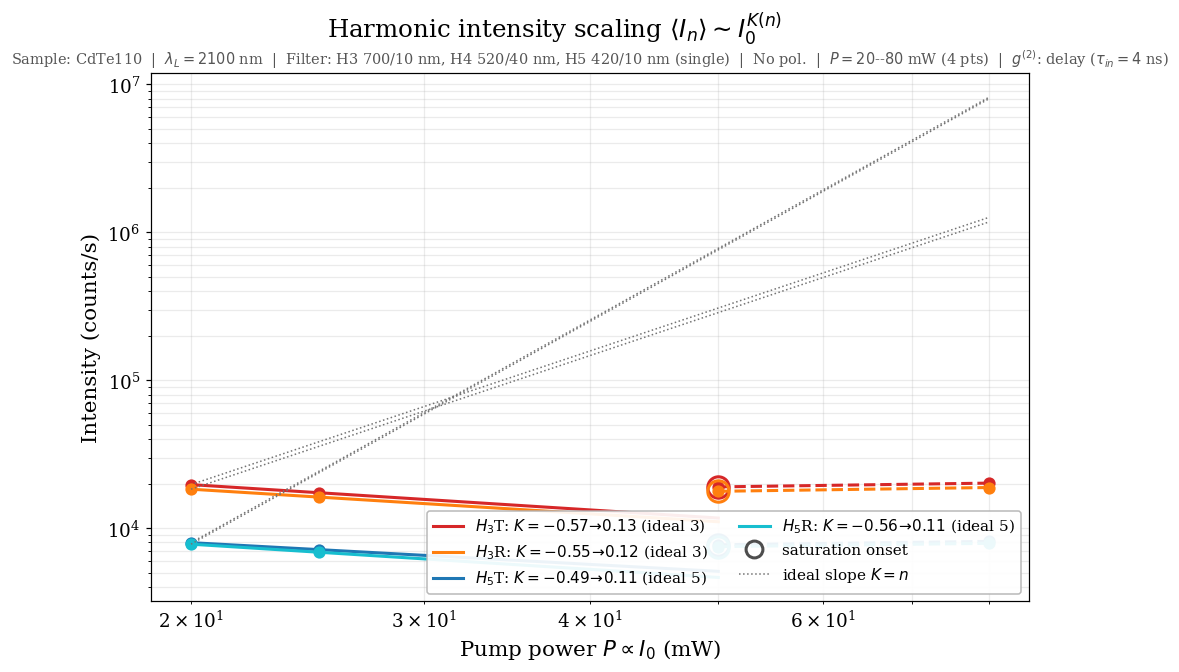

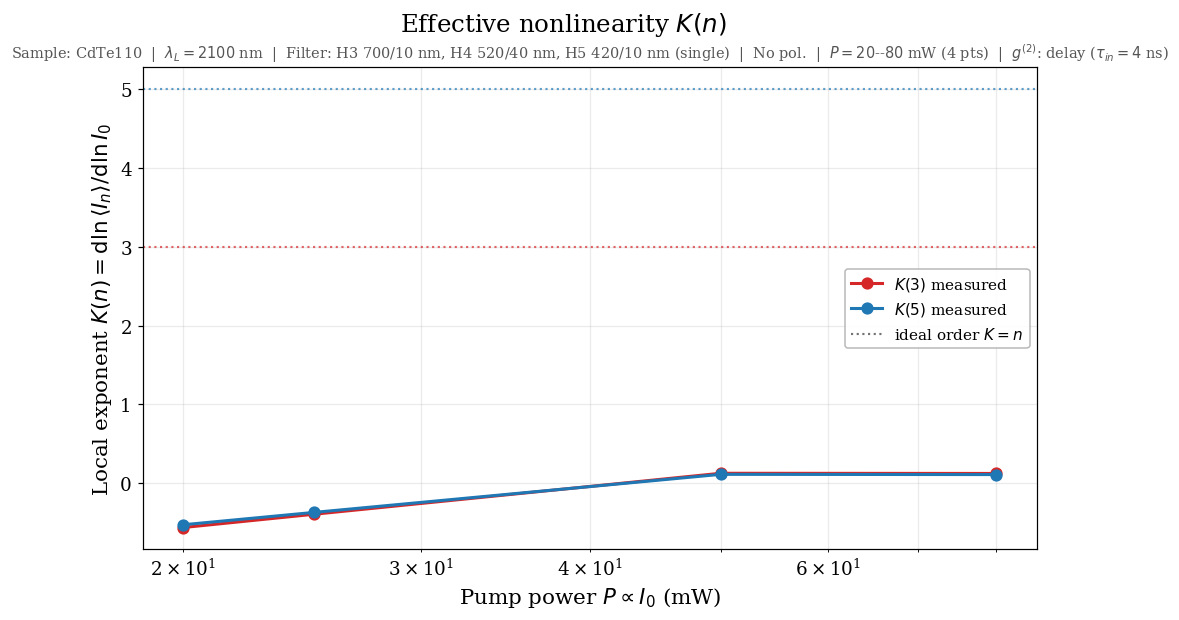

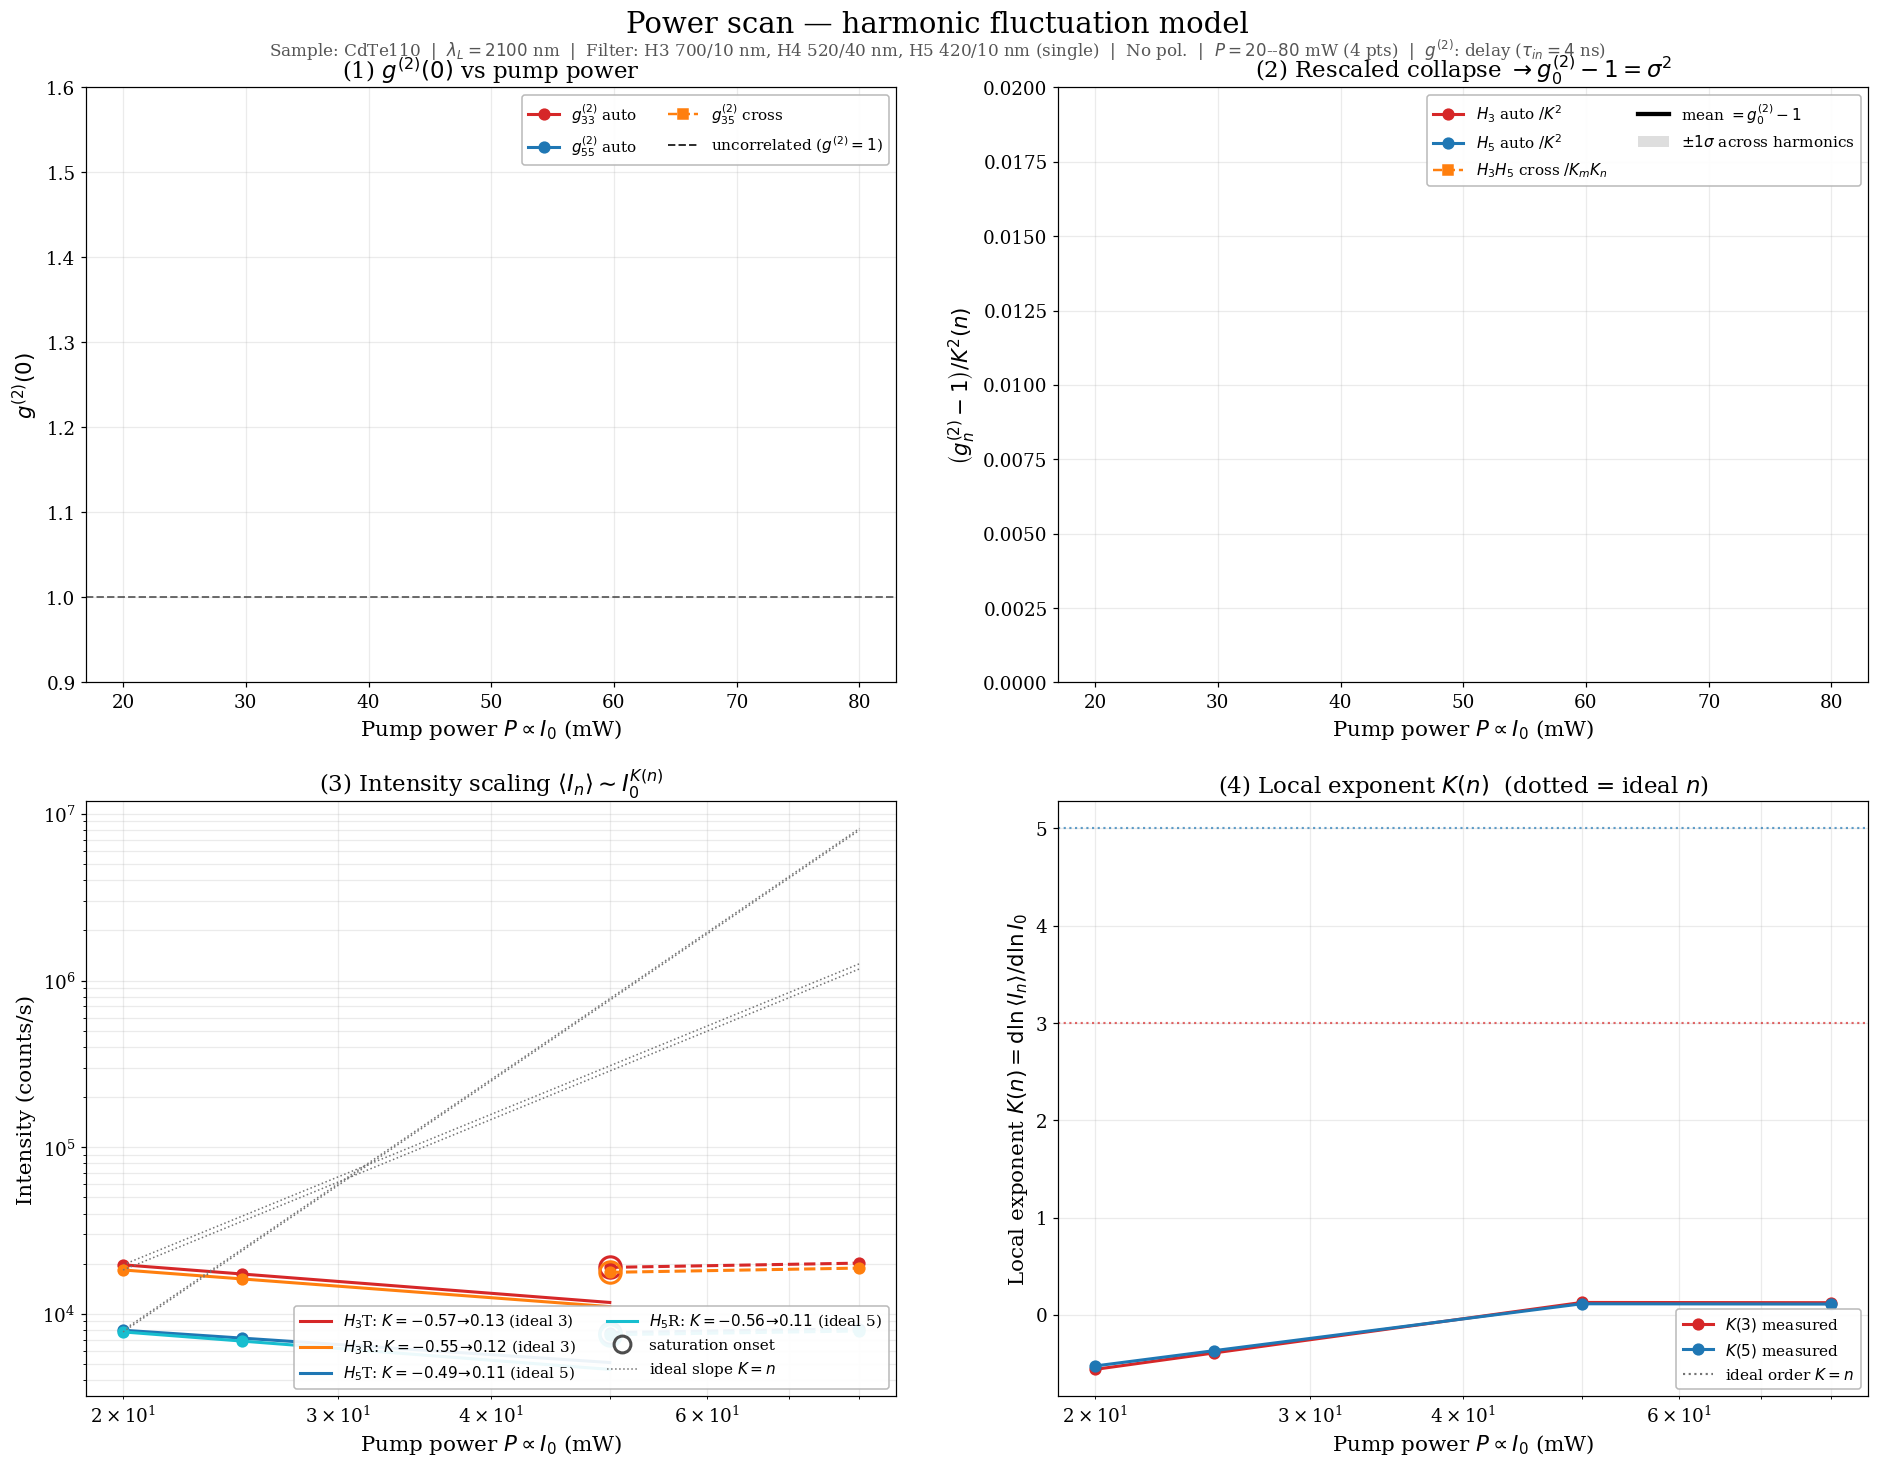

  model -> c:\Users\QUANTUM\Desktop\Quantum_SHHG\results\2026-06-23\POWESCAN__single_700-10_520-40_420-10___NIR3\model


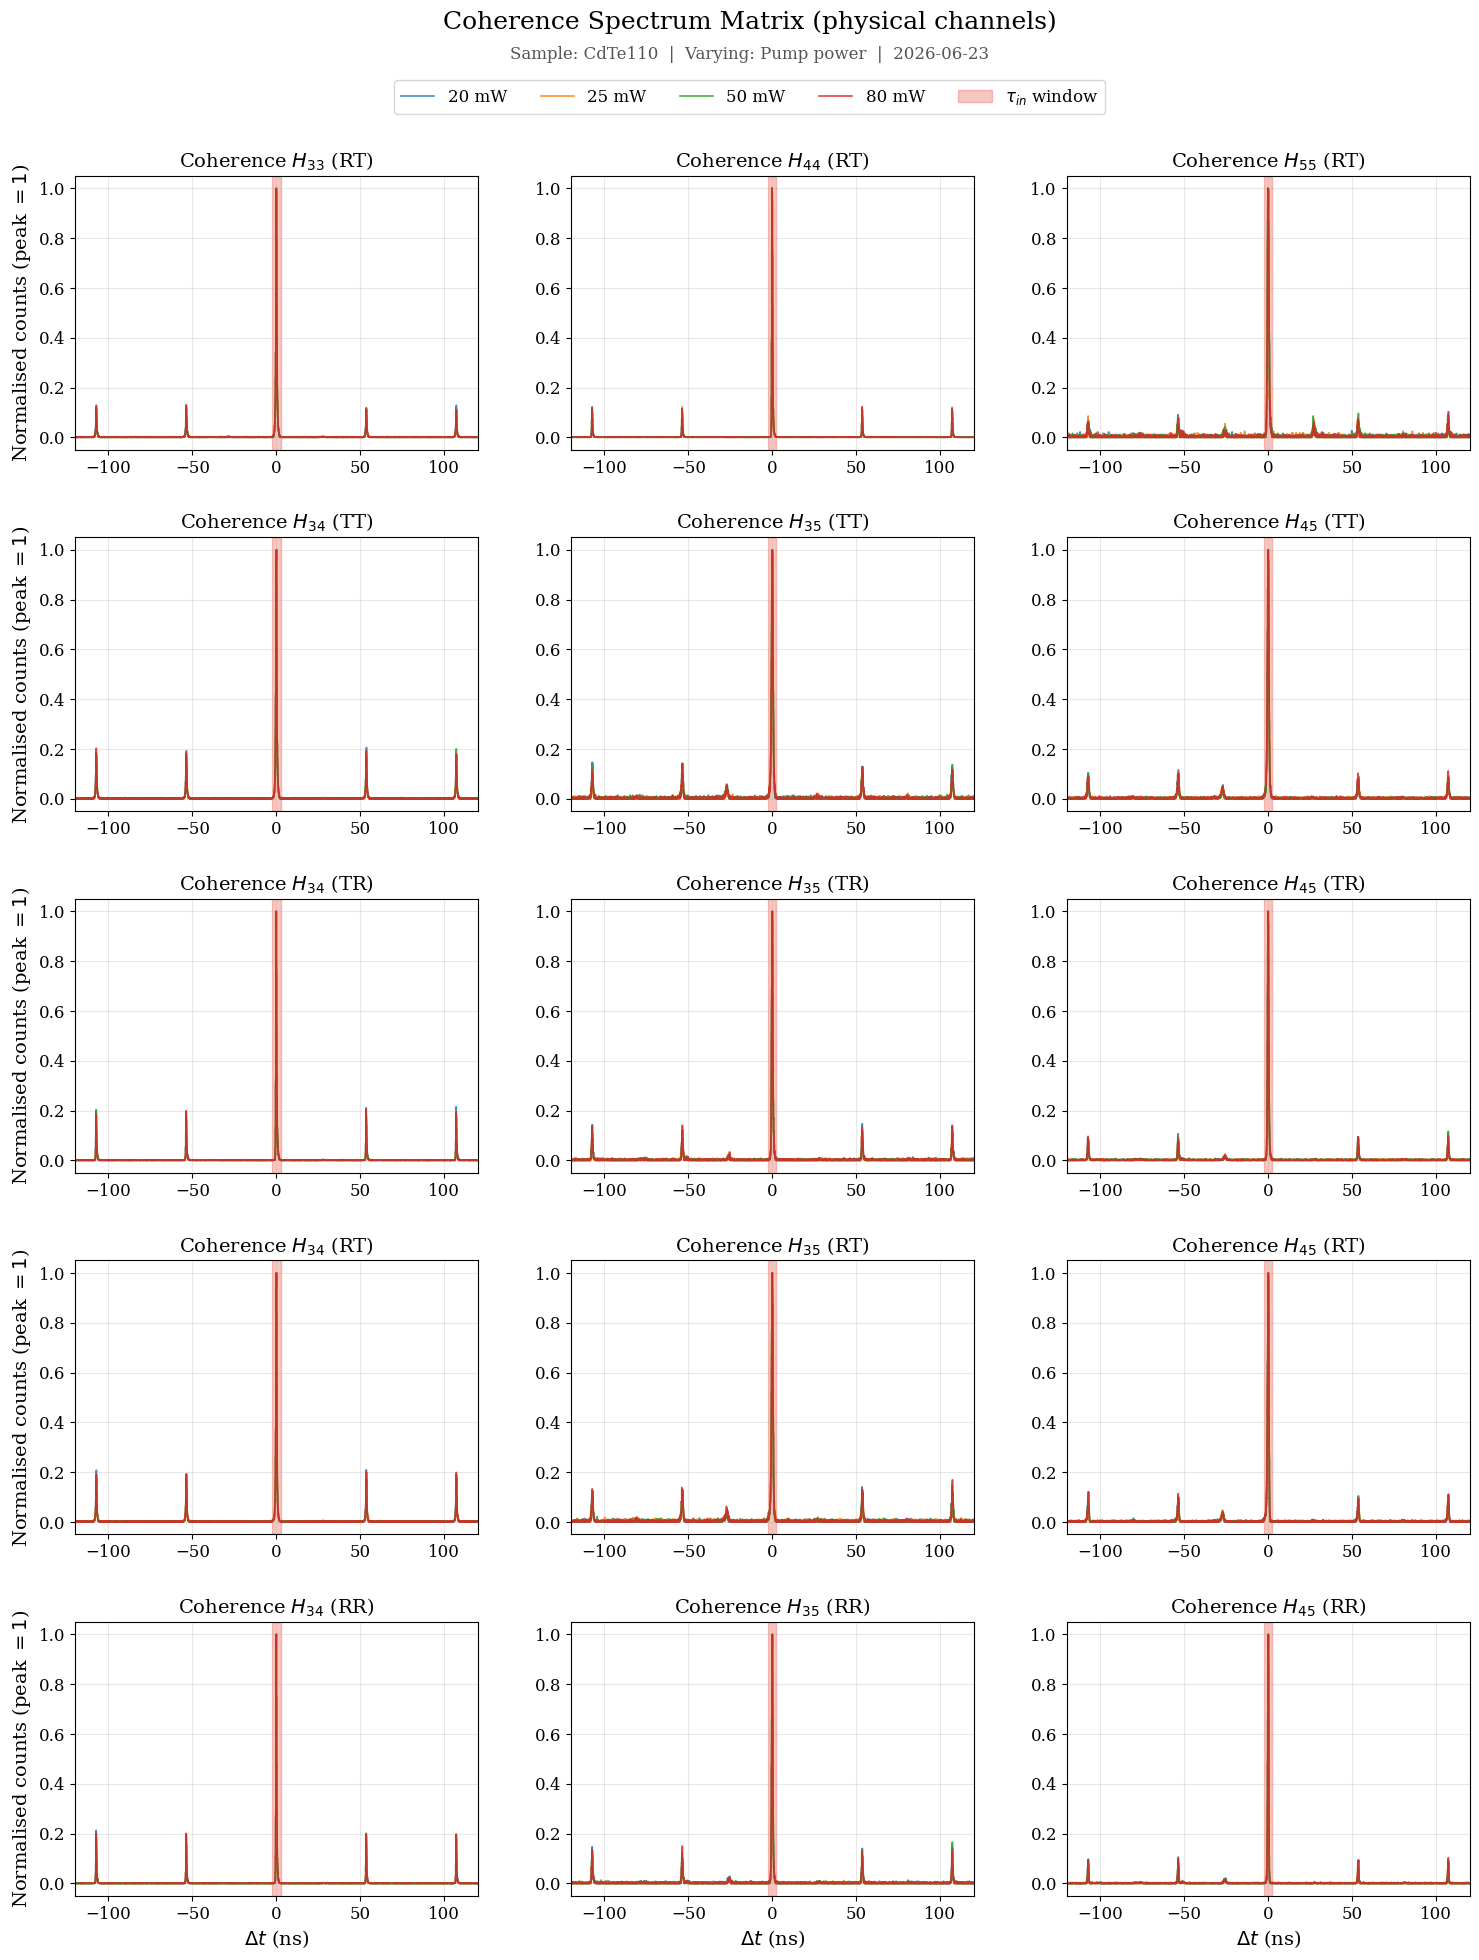

  coherence -> c:\Users\QUANTUM\Desktop\Quantum_SHHG\results\2026-06-23\POWESCAN__single_700-10_520-40_420-10___NIR3\coherence


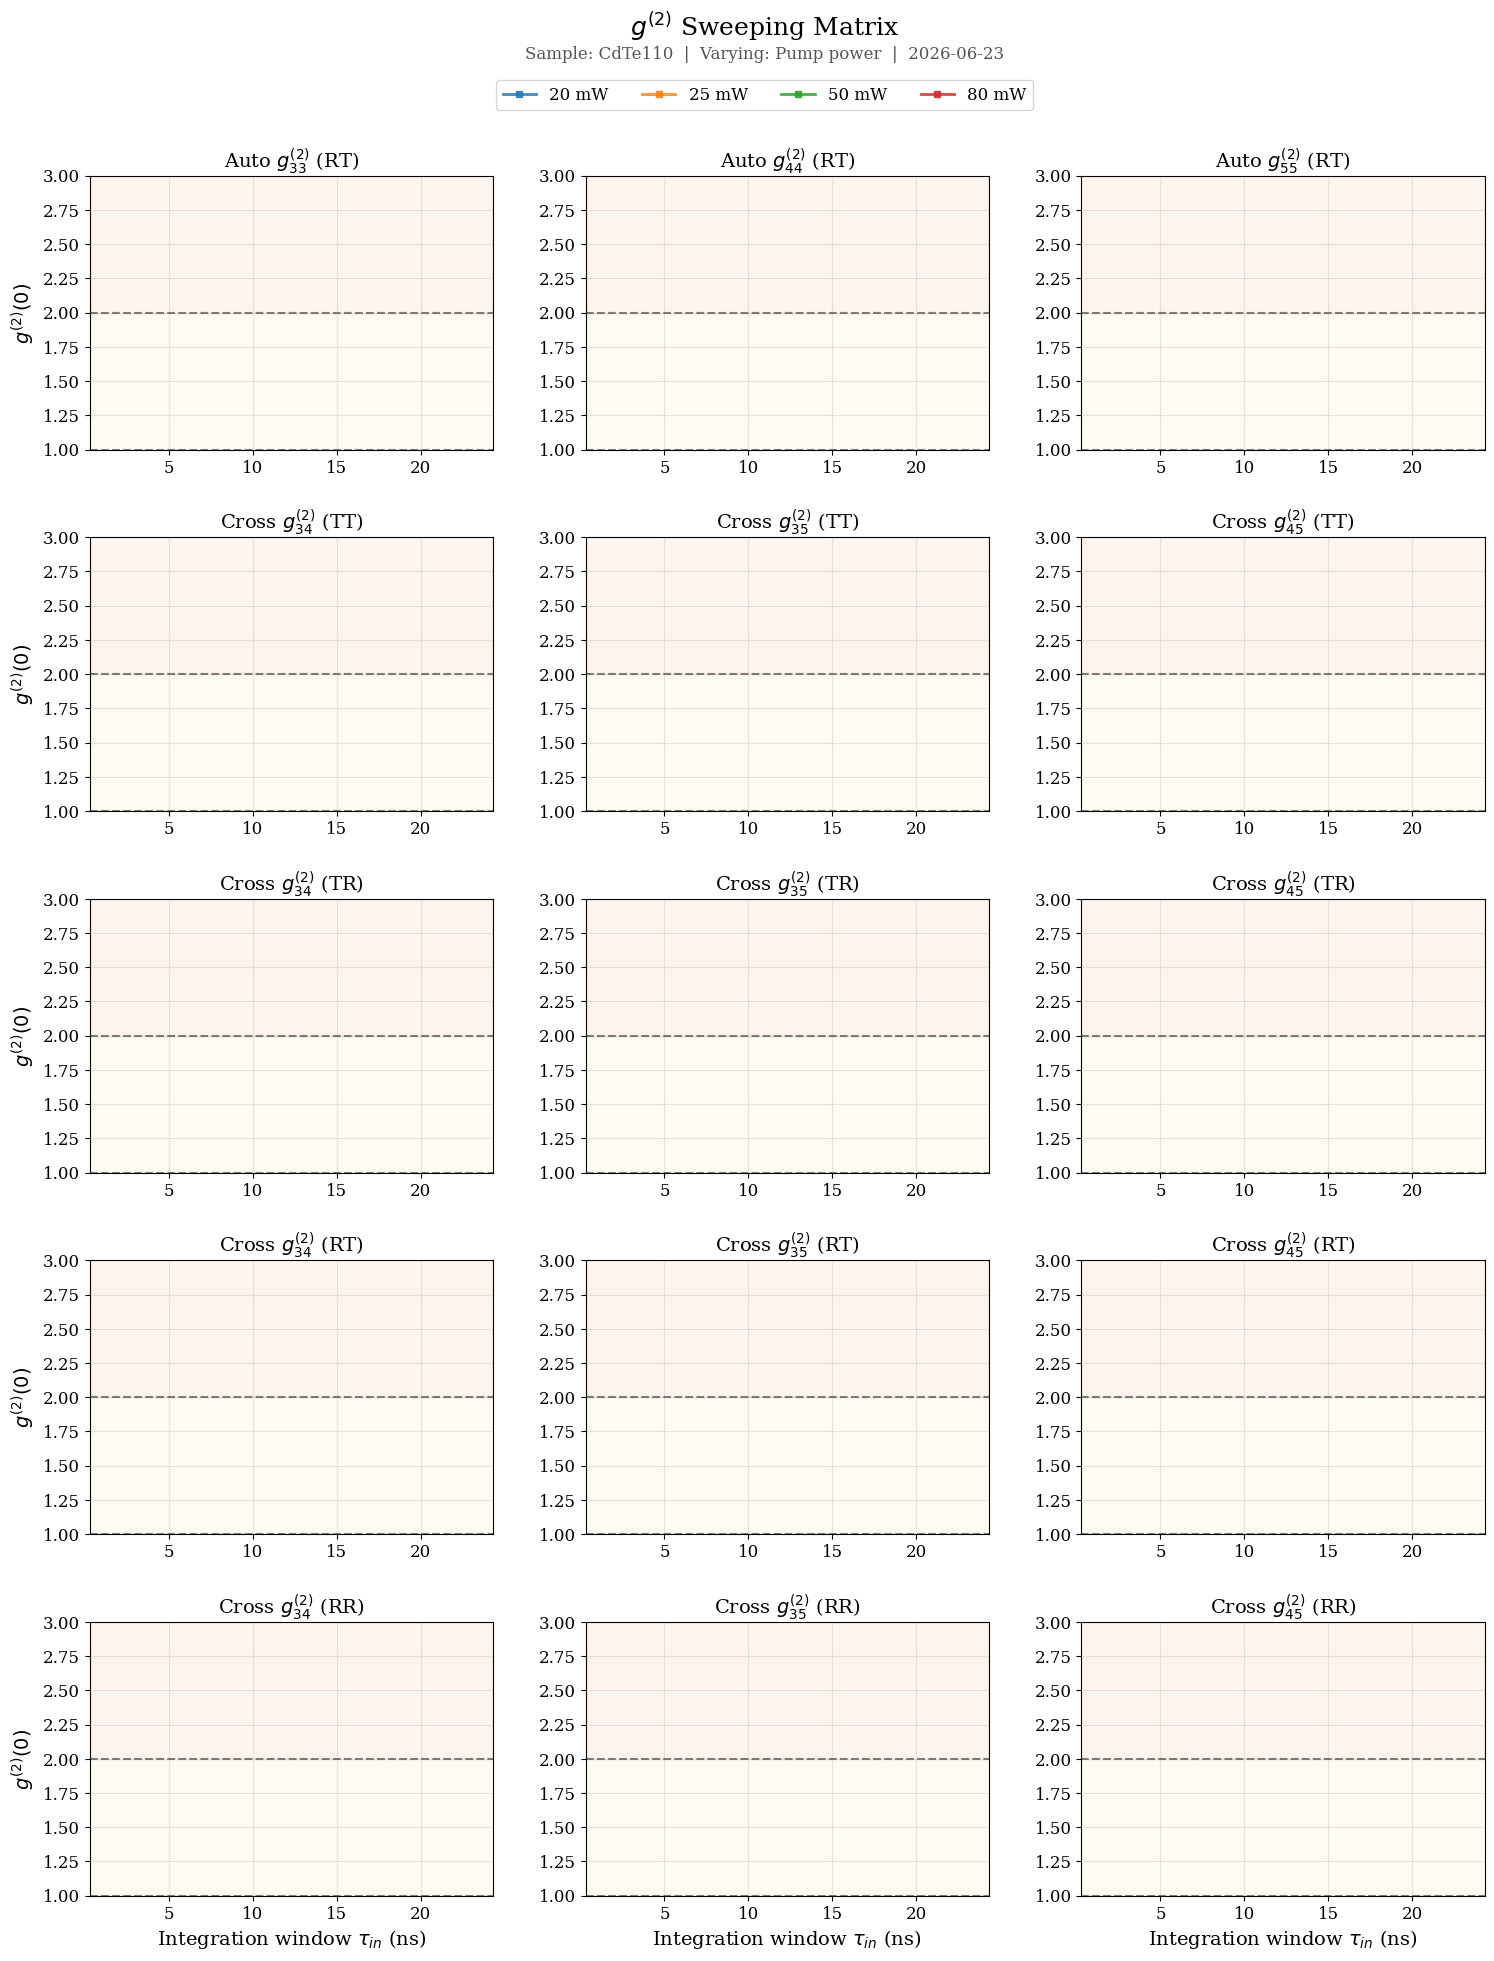

  g2        -> c:\Users\QUANTUM\Desktop\Quantum_SHHG\results\2026-06-23\POWESCAN__single_700-10_520-40_420-10___NIR3\g2


In [ ]:
from src.report import PowerScanReport

rep = PowerScanReport(
    SCAN_PATH, title=TITLE, results_root=RESULTS_DIR,
    intensity_runs=DENSE_PATH, malus=MALUS,
    harmonics=HARMONICS, tau_in_ns=TAU_IN_NS, g2_method=G2_METHOD, k_poly_deg=K_POLY_DEG)

rep.summary()
rep.model(harmonics=HARMONICS, include_cross=True,
          g2_ylim=(0.9, 1.6), collapse_ylim=(0, 0.02), overview=True, show=True)

# correlation grids vs power (optional — comment out to skip)
rep.correlations(
    coherence=dict(xlim=120, integration_window_ns=5.0),
    g2=dict(methods=["delay"], tau_min=0.3, tau_max=25, step=1.0, num_side_peaks=5),
    R=dict(methods=["delay"], tau_min=0.3, tau_max=25, step=1.0, ylim=(0.96, 1.04)))

## 3. Quick zoom

Drag on any figure to zoom, or re-render one model plot with explicit `xlim` / `ylim`.

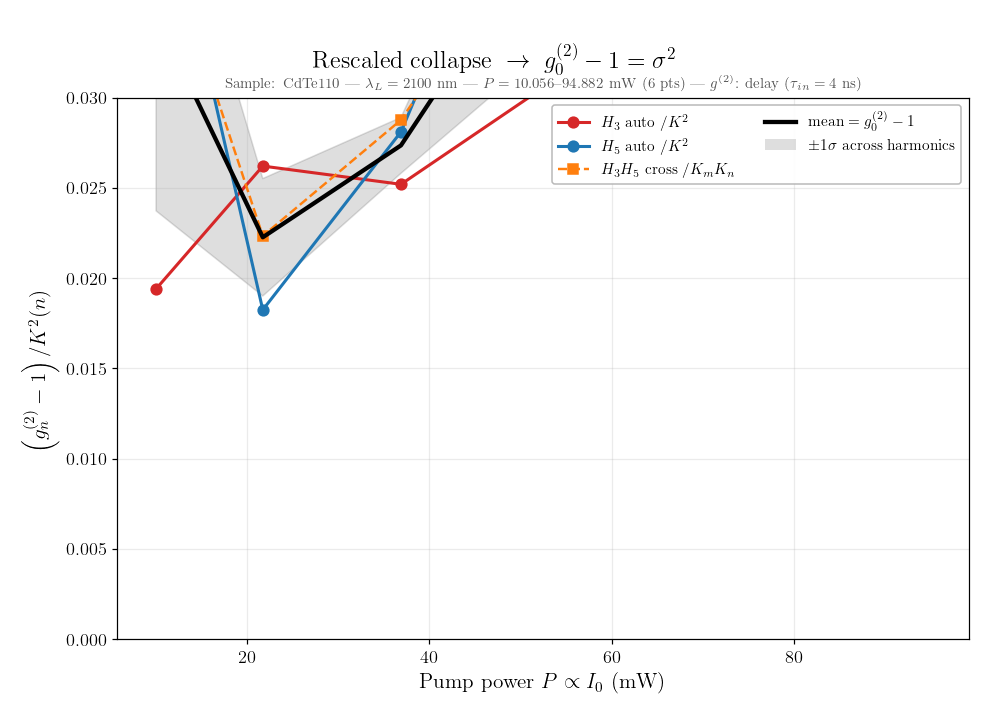

In [ ]:
fig, ax = rep.analyzer.plot_g2_collapse(slope="local", harmonics=HARMONICS, include_cross=True, ylim=(0, 0.03))
rep._display(fig)